# **Demodulation with Advanced Settings**
**Code Example for the heliCam C4**

*24<sup>th </sup> of April 2025, Heliotis AG, Root Lucerne, Switzerland*

This Jupyter Notebook contains documented example code to showcase the control the heliCam C4 - including advanced configuration options - from an interactive Python programming environment.

## Contents
[Getting Started](#Getting-Started)<br>
&emsp;[Notebook Basics](#Notebook-Basics)<br>
&emsp;[Python Setup](#Python-Setup)<br>
&emsp;[Locating C4Utility Installation](#Locating-C4Utility-Installation)<br>
&emsp;[Load Documentation](#Load-Documentation)<br>
[Controlling the heliCam C4](#Controlling-the-heliCam-C4)<br>
&emsp;[Basics](#Basics)<br>
&emsp;&emsp;[Prerequisites](#Prerequisites)<br>
&emsp;&emsp;[Input and Output Control Signals](#Input-and-Output-Control-Signals)<br>
&emsp;&emsp;[Software Interface](#Software-Interface)<br>
&emsp;[Establish Connection](#Establish-Connection)<br>
&emsp;&emsp;[Configure Harvesters](#Configure-Harvesters)<br>
&emsp;&emsp;[Discovering Devices](#Discovering-Devices)<br>
&emsp;&emsp;[Selecting Device](#Selecting-Device)<br>
&emsp;&emsp;[Opening Device](#Opening-Device)<br>
&emsp;[Configuration](#Configuration)<br>
&emsp;&emsp;[Measurement Initiation](#Measurement-Initiation)<br>
&emsp;&emsp;[Lock-In Amplification](#Lock-In-Amplification)<br>
&emsp;&emsp;[Illumination](#Illumination)<br>
&emsp;&emsp;[Output](#Output)<br>
&emsp;&emsp;&emsp;[Image Data](#Image-Data)<br>
&emsp;&emsp;&emsp;[Real-Time Signals](#Real-Time-Signals)<br>
&emsp;[Data Acquisition](#Data-Acquisition)<br>
&emsp;[Validity Check](#Validity-Check)<br>
&emsp;&emsp;[Saturation](#Saturation)<br>
&emsp;&emsp;[Modulation/Demodulation Frequency Mismatch](#Modulation/Demodulation-Frequency-Mismatch)<br>
&emsp;[Processing](#Processing)<br>
&emsp;&emsp;[Offset/Fixed Pattern Noise (FPN) Correction](#Offset/Fixed-Pattern-Noise-%28FPN%29-Correction)<br>
&emsp;&emsp;&emsp;[AlgoLibrary](#AlgoLibrary)<br>
&emsp;&emsp;[Conversion to Polar Coordinates](#Conversion-to-Polar-Coordinates)<br>
[Wrapping Up](#Wrapping-Up)<br>
&emsp;[Freeing Resources](#Freeing-Resources)<br>

## Getting Started

### Notebook Basics

[Jupyter Notebooks](https://jupyter.org/) consist of cells. Active cells can be run using the key combination  ```Shift```+```Enter``` or by pressing the play button &#9658;. The notebook can be reset by restarting the kernel with a click on the corresponding button **&#8634;**. This will remove all stored variables and methods you defined.

Notebooks are inherently interactive. This provides a natural way of controlling the helicam C4, yet also harbors potential pitfalls. In the case of the present notebook, it matters in which order commands are executed. Some cells rely on upstream code having been run or cannot be executed twice. It is thus recommended you once execute the notebook sequentially with default settings to understand the process before you make full use its interactive nature.

### Python Setup

Importing the following python packages is necessary before the rest of this notebook can be run.

In [1]:
import os # interaction with the operating system
import sys # manipulate Python runtime environment
import subprocess # simultaneously running notebook code and web server with html documentation
import time # use time-related functions

import numpy as np # storage and mathematical analysis of camera data
import matplotlib.pyplot as plt # plotting results
import ipywidgets as widgets # interactive control elements

from harvesters.core import Harvester # camera control via GenICam
from packaging.version import parse # compare package versions

### Locating C4Utility Installation

This notebook uses environment variables to locate and access files you installed on your computer as part of the Heliotis software package C4Utility.

***On a Windows computer, the environment variables below have already been set automatically by the C4Utility Installer and no further action is needed. Linux users, on the other hand, must change the type of the following cell from "raw" to "code" and manually add the paths to the C4Utility installation folder and the ```diaphus.cti``` - file contained within.***

### Load Documentation

Further heliCam C4 documentation can thus be localized. The cell below opens it in a web server for cross-referencing it throughout this notebook.

In [2]:
# Code to locate documentation and open it

# Find C4Utility install folder containing (via an environment variable)
pathToC4UtilityRoot = os.path.join(os.getenv('C4UTILITY_ROOT'),'doc')

# Run static http web server to access the documentation in a background process separate from the rest of the notebook
p = subprocess.Popen('python -m http.server --directory "{}" 8000'.format(pathToC4UtilityRoot), start_new_session=True)

After executing the cell above, you should be able to access:
- the [heliCam C4 user manual](http://localhost:8000/heliCamC4_UserManual/) explaining how to set up and use the heliCam C4
- the [feature description](http://localhost:8000/ftrDesc/Root.html) listing all [features](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#feature) of the heliCam C4's application user interface (API) 

## Controlling the heliCam C4

Using Python examples, the software commands required to use the heliCam C4 in its most important operating modes are presented below. The following computer code may serve as a template to be adapted according to your own requirements. Relevant commands may also be copied into independently written application software.

### Basics

Hereafter, only fundamental notions necessary to understand the code examples and reproduce the desired behaviour are explained in the text. For more information, the reader is referred to the heliCam C4 user manual, which provides a brief [introduction to the software control of the heliCam C4](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html).

#### Prerequisites

A correct [hardware](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#hardware-installation) and [software](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#software-installation) setup in accordance with the heliCam C4 user manual is required before proceeding.

#### Input and Output Control Signals

Some of the following camera operating modes allow control signals to be fed in or read out in real time. This is always done via the [heliDriver D3 communication interface](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#communication-interface).

***All input signals must be limited to values between 0 and 5 V. Read-out signals also fall in this range. Both inputs and outputs are usually binary digital signals with a peak-to-peak amplitude of 5 V.
The only exception is the driving signal of the Heliotis LED module, which is in general analogue - regardless of whether input or output.***

If a special input is required (or an output is activated) in a given camera operation mode, it is indicated how the connection is to be made to ensure compatibility with the code.

#### Software Interface 

In this notebook, the heliCam C4 is controlled via the Python library [Harvesters](https://pypi.org/project/harvesters/), one of several [software integration options](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#software-organization-and-integration-options).

### Establish Connection

The first step towards operating the camera is to [establish a connection](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#establishing-network-connection) to it in the first place.

#### Configure Harvesters

For this purpose, Harvesters must be provided with a path to the computer-side Heliotis driver software that enables it to communicate with the camera.

In [3]:
h = Harvester()
# Find (the driver software) Diaphus' CTI-file via environment variable ...
pathToDiaphusCtiFile = os.getenv("DIAPHUS_GENTL64_FILE") 
# ... and declare its location to harvesters.
h.add_file(pathToDiaphusCtiFile)

#### Discovering Devices

Now, Harvester’s internal list of devices that it can control may be updated to find the camera in the local network.

In [4]:
h.update()

#### Selecting Device

To make selection as convenient as possible, this list of available devices is displayed in the form of a [Jupyter Widget](https://ipywidgets.readthedocs.io/en/stable/). A similar interactive format is subsequently implemented for other selection options.

In [5]:
options = [f"{dev.id_}  (SN: \"{dev.serial_number}\")" for dev in h.device_info_list]
description = f"{len(h.device_info_list)} device(s) detected : "

w = widgets.RadioButtons(options=options, description=description,layout={'width': 'max-content'},style= {'description_width': 'initial'})
display(w)


RadioButtons(description='3 device(s) detected : ', layout=Layout(width='max-content'), options=('DiaphusTL_DE…

***If your heliCam C4 has not been detected, try restarting the kernel and running all cells once more. Should the camera still be unavailable, proceed by checking the [hardware](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#checking-the-hardware-setup) and the [software](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#checking-the-software-setup) setup.***

#### Opening Device

A virtual camera object is now created through which the heliCam C4 can be controlled. Other user applications can no longer access the heliCam C4 via its programming interface, until it is [released](#Freeing-Resources) in this notebook.

In [6]:
camera = h.create(w.index) # create a camera object for the selected device

### Configuration

Once the connection has been established, the heliCam C4 is by default in configuration mode. In this state, measurement parameters may be set via the camera object before a recording is started. 

#### Measurement Initiation

The heliCam C4 records a sequence of [frames](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#frame) each time a measurement is initiated. Starting the acquisition of such a frame burst, like the rest of the [camera sensor's time schedule](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#temporal-sequence), is controlled by [trigger signals](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#status-trigger-and-event). Their configuration is detailed here.

In practice, two ways of initiating a measurement are relevant:
- The transmission of a trigger signal from a software development environment to the camera is subject to a significant, variable, and computer-dependent time delay. Yet if there is *no need for precise control of its timing*, a recording may nonetheless be triggered simply by ***software command*** for the sake of convenience. 
- Sometimes, however, the start of the measurement must be *precisely synchronized with other experimental components*. In this case, the recording should be triggered in real time with an ***external signal***.

Two trigger signals are required in series to initiate a measurement:

- First, the camera waits for the ``FrameStart`` trigger, which brings it in a state of preparedness for a new frame burst.
- The camera only starts the recording sequence immediately after it receives an additional ``RecodingStart`` trigger.

Hence, there is often not just a single valid way of configuring triggers as required. The most straightforward and recommended approach is to leave the settings of the ``FrameStart`` trigger at their default value, i.e., ``Software`` triggered. The two relevant measurement initiation modes can then be realized solely by with an appropriate configuration the ``RecordingStart`` trigger.

In this case, which is implemented here, the ``FrameStart`` signal is always generated first using the software command [``TriggerSoftware.execute()``](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerSoftware.html) (see [Acquisition Data](#Data-Acquisition)). The ``RecordingStart`` trigger then initiates the recording without delay and, unlike the ``FrameStart`` trigger, it can be of external origin. If the timing is not to be controlled, the ``RecordingStart`` trigger is configured so that the measurement start is initiated as soon as the camera registers the ``FrameStart`` trigger.

The following [features](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#feature) are relevant for the configuration of the ``RecordingStart`` trigger (and all other triggers that are not reconfigured here):
- [``TriggerSelector``](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerSelector.html), a [selector](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#selector), determines for which trigger (here ``RecodingStart``) the following two features under its control are configured.
- [``TriggerMode``](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerMode.html), an on/off switch, whether the selected trigger must actually be sent to the camera or is simply auto-generated by the camera itself at the first possible moment.
- [``TriggerSource``](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerSource.html) enables the selection of the physical or internal channel on which the trigger is to be received.

If you configure the camera to receive an external ``RecordingStart`` trigger, provide a [valid input](#Input-and-Output-Control-Signals) to the [communication interface](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#communication-interface) pin selected as its ``TriggerSource`` (here ``FI2``). By default, the first [rising edge](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerActivation.html) after the camera received the ``FrameStart`` signal triggers the onset of the recording.

In [7]:
def measurementInitConfig(camera,measurementInitiationMode='external'):
    """
    Configure RecordingStart trigger depending on whether the measurement
    is to be initiated via an internal (software) generated signal
    or an external real-time input through a physical D3 pin.
    """

    camera.remote_device.node_map.TriggerSelector.value = 'RecordingStart'
    
    if measurementInitiationMode == 'internal':

        camera.remote_device.node_map.TriggerMode.value = 'Off'

    elif measurementInitiationMode == 'external':
   
        camera.remote_device.node_map.TriggerMode.value = 'On'
        camera.remote_device.node_map.TriggerSource.value = 'FI2'

    camera.remote_device.node_map.TriggerSelector.value = 'FrameStart'
    camera.remote_device.node_map.TriggerMode.value = 'On'
    camera.remote_device.node_map.TriggerSource.value = 'Software'


In [8]:
# Code for interactive selection of measurement initiation mechanism
    
widgets.interact(measurementInitConfig, camera=widgets.fixed(camera),
                measurementInitiationMode=widgets.RadioButtons(options=[('Software Trigger Only','internal'),
                                                                        ('External Trigger (on FI2)','external')],
                                                                        value='internal',
                                                                        description='Measurement Initiation',
                                                                        disabled=False, layout={'width': 'max-content'},
                                                                        style= {'description_width': 'initial'}));

C:\Users\balz.marty\.virtualenvs\env-3u-IasYl\Lib\site-packages\ipywidgets\widgets\interaction.py:44: DeprecationWarning: `ipykernel.pylab.backend_inline` is deprecated, directly use `matplotlib_inline.backend_inline`
  from ipykernel.pylab.backend_inline import flush_figures


interactive(children=(RadioButtons(description='Measurement Initiation', layout=Layout(width='max-content'), o…

#### Lock-In Amplification

Initially, the heliCam C4 must be set to lock-in camera mode using the [`DeviceOperationMode`](http://localhost:8000/ftrDesc/Root/MiscControl/DeviceOperationMode.html#deviceoperationmode) feature. This allows the configuration of the camera as a lock-in amplifier (LIA).

In [9]:
camera.remote_device.node_map.DeviceOperationMode.value = 'LockInCam'

All the features listed below can be found in the [lock-in control section](http://localhost:8000/ftrDesc/Root/LockInControl.html) of the API description. (If necessary, a [detailed theoretical explanation](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#d-advanced-concepts-and-control) of the lock-in principle and its heliCam C4 implementation is provided in the user manual).

Relevant for all LIA configurations are:

* [`LockInTargetReferenceFrequency`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInTargetReferenceFrequency.html), the [reference frequency](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#lock-in-amplification). For [technical reasons](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#reference-signal-synthesis), it must be set accurately even if an external reference (trigger) signal is provided.
* [`LockInTargetTimeConstantNPeriods`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInTargetTimeConstantNPeriods.html), the number of full periods of the reference signal during which the image sensor is integrating photocurrent per frame. A higher number leads to a narrower filter bandwidth and usually increases the signal level.
* [`LockInTargetBlankDurationNPeriods`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInTargetBlankDurationNPeriods.html), the number of additional full periods of the reference signal per frame during which the image sensor is not integrating any photocurrent. A higher number leads to sparser sampling in time with the same amount of signal.
* [`LockInSensitivity`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInSensitivity.html) which, roughly speaking, controls the exposure time of the image sensor. Lowering the sensitivity decreases the signal level.
* [`LockInCoupling`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInCoupling.html) which allows selecting ``AC`` or ``DC`` coupling in analogy to electronic instruments. ``AC`` coupling, generally speaking, removes the static background prior to lock-in amplification to prevent saturation in certain situations.
* [`LockInReferenceSourceType`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInReferenceSourceType.html) which determines whether the reference clock is derived from an ``Internal`` or ``External`` local oscillator.

Meaningful only if an external reference (trigger) signal is used (i.e., `LockInReferenceSourceType = 'External'`) are:

* [`LockInReferenceSourceSignal`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInReferenceSourceSignal.html) which specifies the input pin on the heliDriver D3's [communication interface](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#communication-interface) used as the source for the reference signal.
* [`LockInReferenceFrequencyScaler`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInReferenceFrequencyScaler.html) which specifies a scaling factor applied to the frequency of the external reference (trigger) signal before it reaches the lock-in sensor. *Note that frequency synthesis is disabled if `LockInReferenceFrequencyScaler = 'DivideBy4'`. Then, each external trigger directly starts a new [quarter period](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#quarter-period) in the image sensor.*
* [`LockInTargetExpectedFrequencyDeviation`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInExpectedFrequencyDeviation.html) which is set to handle uncertainty in the external reference (trigger) signal's frequency up to the indicated percentage value. The sensor compensates for jitter and systematic offset in frequency with a lower exposure time. A higher deviation setting thus leads to less signal.
* [`LockInReferenceTimeShift`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInReferenceTimeShift.html) which can be used to add a configurable time delay to the external reference (trigger) signal.

*Note that:*
- *All [target feature](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#target-and-actual) values may differ slightly from actual values due to rounding. Here, actual values can be read out via the features [LockInActualReferenceFrequency](http://localhost:8000/ftrDesc/Root/LockInControl/LockInActualReferenceFrequency.html) and [LockInActualTimeConstantNPeriods](http://localhost:8000/ftrDesc/Root/LockInControl/LockInActualTimeConstantNPeriods.html), respectively.*
- *Some settings may produce a [frame rate violation](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#frame-rate) leading to insufficient data amounts and errors.*

In [10]:
def lockInAmplificationConfig(camera, sensitivity=0.5,TimeConstant=10,BlankDuration=0,coupling='DC',
                              referenceFrequency=10000,referenceSourceType='Internal',
                              referenceSourceSignal='FI3',referenceFrequencyScaler='Off',
                              expectedFrequencyDeviation=1):
    """
    Configure the heliCam C4's lock-in amplification.
    """
    
    camera.remote_device.node_map.LockInSensitivity.value = sensitivity
    camera.remote_device.node_map.LockInTargetTimeConstantNPeriods.value = TimeConstant
    if parse(camera.remote_device.node_map.DeviceFirmwareVersion.value) > parse('1.9.2'):
        camera.remote_device.node_map.LockInTargetBlankDurationNPeriods.value = BlankDuration
    camera.remote_device.node_map.LockInCoupling.value = coupling
    camera.remote_device.node_map.LockInTargetReferenceFrequency.value = referenceFrequency

    if referenceSourceType == 'Internal':

        camera.remote_device.node_map.LockInReferenceSourceType.value = 'Internal'
        
    elif referenceSourceType == 'External':
    
        camera.remote_device.node_map.LockInReferenceSourceType.value = 'External'
        camera.remote_device.node_map.LockInReferenceSourceSignal.value = referenceSourceSignal
        camera.remote_device.node_map.LockInReferenceFrequencyScaler.value = referenceFrequencyScaler
        camera.remote_device.node_map.LockInExpectedFrequencyDeviation.value = expectedFrequencyDeviation


The following cells uses widgets to interactively provide the LIA configuration function with input values of your choosing.

Valid settings (producing decent signal levels while avoiding [saturation](#Saturation)) depend on the sensor type - which vary in pixel-size, fill factor, and full well capacity (see details [here](http://localhost:8000/heliCamC4_UserManual/chapter1/chapter1.html#specifications)). With firmware version > v1.9.2, the sensor type is read from the camera memory and the default values are adjusted accordingly. If you use older firmware, however, you need to adjust the sensitivity manually according to the sensor type noted on the camera with the interactive slider below to receive good quality data.

|  | C4-S40 | C4-S40U | C4-S41U | C4M |
| --- | --- | --- | --- | --- |
| Sensitivity | 0.5 | 0.2 | 0.05 | 0.25 |

In [11]:
# Code for sensitivity default value configuration according to sensor type if possible

deviceFrimwareVersion = camera.remote_device.node_map.DeviceFirmwareVersion.value
print('You are using firmware {}.\n'.format(deviceFrimwareVersion))

if parse(deviceFrimwareVersion) > parse('1.9.2'):

    match camera.remote_device.node_map.SensorName.value:
        case 'S40 (500k full well, no microlenses)':
            sensitivityInit = 0.5
        case 'S40U (500ke full well, with microlenses)':
            sensitivityInit = 0.2
        case 'S41U (125ke full well, with microlenses)':
            sensitivityInit = 0.05
        case 'S4M (no microlenses)':
            sensitivityInit = 0.25
        case _:
            'The sensor type could not be read from the camera.'
            sensitivityInit = 0.5

else:
    print('For a valid example set of parameters, adjust the Sensitivity in the interactive menu\
 below according to the table above.'.format(deviceFrimwareVersion))
    sensitivityInit = 0.5

You are using firmware 1.10.2b.



In [12]:
# Code for interactive LIA configuration

# read features' validity limits
expectedFrequencyDeviationMin = camera.remote_device.node_map.LockInExpectedFrequencyDeviation.min
expectedFrequencyDeviationMax = camera.remote_device.node_map.LockInExpectedFrequencyDeviation.max

sensitivityMin = camera.remote_device.node_map.LockInSensitivity.min
sensitivityMax = camera.remote_device.node_map.LockInSensitivity.max

TimeConstantMin = camera.remote_device.node_map.LockInTargetTimeConstantNPeriods.min
TimeConstantMax = camera.remote_device.node_map.LockInTargetTimeConstantNPeriods.max

BlankDurationMin = camera.remote_device.node_map.LockInTargetBlankDurationNPeriods.min
BlankDurationMax = camera.remote_device.node_map.LockInTargetBlankDurationNPeriods.max
blankDurationDisabled = True if parse(camera.remote_device.node_map.DeviceFirmwareVersion.value) <= parse('1.9.2') else False

referenceFrequencyMin = camera.remote_device.node_map.LockInTargetReferenceFrequency.min
referenceFrequencyMax = camera.remote_device.node_map.LockInTargetReferenceFrequency.max-1

couplingOptions = camera.remote_device.node_map.LockInCoupling.symbolics
referenceSourceTypeOptions = camera.remote_device.node_map.LockInReferenceSourceType.symbolics

isC4 = camera.remote_device.node_map.Height.value == 542 \
    and camera.remote_device.node_map.Width.value == 512 # test whether C4 or C4M is connected



# Initialize widgets

camera.remote_device.node_map.SensorName.value

wSensitivity = widgets.FloatSlider(min=sensitivityMin,max=sensitivityMax,value=sensitivityInit,step=0.01,
                                   description="Sensitivity",style={'description_width': 'initial'})
wTimeConstant = widgets.IntSlider(min=TimeConstantMin,max=TimeConstantMax,step=1,value=10,
                              description="# of Demodulated Periods",style={'description_width': 'initial'})
wBlankDuration = widgets.IntSlider(min=BlankDurationMin,max=BlankDurationMax,step=1,value=0,
                              description="# of Blank Periods",style={'description_width': 'initial'},
                              disabled=blankDurationDisabled)
wCoupling = widgets.RadioButtons(options=couplingOptions,value='DC',description= "Coupling")           
wReferenceFrequency = widgets.FloatLogSlider(base=10,step=0.0001,value=10000,
                                             min=np.log10(referenceFrequencyMin),
                                             max=np.log10(referenceFrequencyMax),
                                             description="Reference Frequency in Hz",
                                             style={'description_width': 'initial'})
wReferenceSourceType = widgets.RadioButtons(options=referenceSourceTypeOptions,value = 'Internal',
                                            description='Reference Source Type',
                                            style={'description_width': 'initial'})
wReferenceFrequencyScaler = widgets.Dropdown(options=['Off','DivideBy4'],value='Off',                                             
                                             description="Reference Frequency Scaler",
                                             style={'description_width': 'initial'},
                                             disabled=True,layout={'left': '25px'})
wReferenceSourceSignal = widgets.Dropdown(options=['FI3'],value='FI3',disabled=True,
                                          description="Reference Source Signal",
                                          style={'description_width': 'initial'},
                                          layout={'left': '25px'})
wExpectedFrequencyDeviation = widgets.IntSlider(min=expectedFrequencyDeviationMin,
                                                max=expectedFrequencyDeviationMax,value=1,
                                                step=1,description="Exp. Frequency Deviation in %",
                                                style={'description_width': 'initial'},disabled=True,
                                                layout={'left': '25px'})

def updateLIAWidgets(change):
    """
    Auxiliary function to enable/disable widgets
    relevant only in external reference configuration.
    """
    disabled = change['new']=='Internal'
    wReferenceSourceSignal.disabled = disabled
    wReferenceFrequencyScaler.disabled = disabled
    wExpectedFrequencyDeviation.disabled = disabled

# couple interdependent widgets
wReferenceSourceType.observe(updateLIAWidgets, names='value') 

# configure and display global widget
widgets.interact(lockInAmplificationConfig, camera=widgets.fixed(camera),
                 sensitivity = wSensitivity,TimeConstant = wTimeConstant, BlankDuration = wBlankDuration, coupling = wCoupling,
                 referenceFrequency = wReferenceFrequency, referenceSourceType = wReferenceSourceType,
                 referenceSourceSignal = wReferenceSourceSignal, 
                 referenceFrequencyScaler = wReferenceFrequencyScaler,
                 expectedFrequencyDeviation = wExpectedFrequencyDeviation);

# display frame rate diagnostics
wFrameRateValidity = widgets.Valid(value=True,description='Frame Rate',)

def updateFrameRate(_):
    """
    Auxiliary function testing for frame rate viaolation
    """
    if isC4:
        frameRateLimit = 4960 # in Hz
    else: # Case C4M
        frameRateLimit = 1390 # in Hz
    
    validFrameRate = (wTimeConstant.value+wBlankDuration.value-0.5+int(wCoupling.value=='AC')) \
                / (wReferenceFrequency.value*(1+int(wReferenceSourceType.value=='External') \
                                            * wExpectedFrequencyDeviation.value/100)) \
                - (wTimeConstant.value+wBlankDuration.value-0.5)*6.3*1e-6 > 1/frameRateLimit
        
    wFrameRateValidity.value = validFrameRate

wTimeConstant.observe(updateFrameRate, names='value')
wBlankDuration.observe(updateFrameRate, names='value')
wCoupling.observe(updateFrameRate, names='value')
wReferenceFrequency.observe(updateFrameRate, names='value')
wReferenceSourceType.observe(updateFrameRate, names='value')
wExpectedFrequencyDeviation.observe(updateFrameRate, names='value') 

wFrameRateValidity

interactive(children=(FloatSlider(value=0.5, description='Sensitivity', max=1.0, step=0.01, style=SliderStyle(…

Valid(value=True, description='Frame Rate')

#### Illumination

The [LED module](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#led-module) can be used to generate optical input signals for commissioning and testing the heliCam C4. It can be used in three possible operating modes, which can be selected via the [``LightControllerSource``](http://localhost:8000/ftrDesc/Root/LightControl/LightControllerSource.html) feature:

- switched off completely
- driven by an analogue external signal (0-5V) delivered to a selectable pin on the heliDriver D3's . (Here, [the default pin SFIO5](http://localhost:8000/heliCamC4_UserManual/_downloads/aeb130361aecb1f41ec682f7001d0ba2/D3ds-appendixI.pdf) is chosen.)
- driven by a configurable [signal generator](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#illumination-control) (in the heliDriver D3)

With the latter option, the following parameters are available to configure the sinusoidal signal that is generated:

- [`SignalGeneratorFrequency`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorFrequency.html) sets the frequency of the signal. (In this notebook, the default setting is slightly different from the reference frequency. Thus, a beat is produced. Mathematical details are found [here](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#idealized-signal-processing).)
- [`SignalGeneratorAmplitude`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorAmplitude.html) sets the peak-to-peak amplitude of the signal in percent of the full range.
- [`SignalGeneratorOffset`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorOffset.html) sets the amplitude of the signal in percent of the full range. Part of the signal thus gets cropped if:

$$Offset - \frac{Amplitude}{2}<0\% \ \ \ or \ \ \ Offset + \frac{Amplitude}{2}>100\%$$

- [`SignalGeneratorModulationMode`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorMode.html) determines how the (intensity) modulation is applied. Three modes are available:
    - ``'On'``: The signal generator produces a continuous sinusoidal test signal for the heliCam C4.
    - ``'Off'``: The sinusoidal intensity modulation is switched off and only the constant offset remains. This setting is important for [measuring](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#measuring-offset) and [substracting](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#conversion-to-polar-coordinates) the offset due to [fixed pattern noise](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#fixed-pattern-noise).
    - ``'Pulsed'``: In the pulsed mode, the LED emits sinusoidal bursts. In between individual bursts, the illumination is constant and given by the Offset. Additional parameters govern the pulse characteristics.
        - [`SignalGeneratorTriggerSource`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorTriggerSource.html) specifies the [Communication Interface](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#communication-interface) pin used to trigger the next burst (here ``'RTIO6'``). In `Auto` mode, the trigger is generated automatically as soon as the set ``Pulse Duration`` and ``Trigger Delay`` allow it.
        - [`SignalGeneratorPulseDuration`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorPulseDuration.html) sets the duration of a single burst.
        - [`SignalGeneratorTriggerActivation`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorTriggerActivation.html) specifies the flank of the trigger signal, which is detected.
        - [`SignalGeneratorTriggerDelay`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorTriggerDelay.html) introduces a delay of the modulation burst with respect to the trigger.
        - [`SignalGeneratorPhaseShift`](http://localhost:8000/ftrDesc/Root/LightControl/SignalGeneratorPhaseShift.html) sets a common phase shift all modulation bursts are subjected to.


In [13]:
def illuminationConfig(camera,illuminationDriverMode='SignalGenerator',signalGeneratorModulationMode='On',
                       signalGeneratorOffset=50,signalGeneratorAmplitude=100,signalGeneratorFrequency=9975,
                       signalGeneratorTriggerSource='RTIO6',signalGeneratorPulseDuration=2000):
    """
    Configure the illumination by the Heliotis LED module.
    """

    if illuminationDriverMode == 'Off':
        
        # Switch the LED to off
        camera.remote_device.node_map.LightControllerSource.value = 'Off'

    try: 

        if illuminationDriverMode == 'SignalGenerator':
            
            # Use the internal signal generator to drive the LED
            camera.remote_device.node_map.LightControllerSource.value = 'SignalGenerator'

            camera.remote_device.node_map.SignalGeneratorOffset.value = signalGeneratorOffset
            camera.remote_device.node_map.SignalGeneratorAmplitude.value = signalGeneratorAmplitude
            camera.remote_device.node_map.SignalGeneratorFrequency.value = signalGeneratorFrequency

            camera.remote_device.node_map.SignalGeneratorMode.value = signalGeneratorModulationMode # ['On','Off','Pulsed']

            if signalGeneratorModulationMode == 'Pulsed':

                camera.remote_device.node_map.SignalGeneratorTriggerSource.value = signalGeneratorTriggerSource
                camera.remote_device.node_map.SignalGeneratorPulseDuration.value = signalGeneratorPulseDuration
        
            time.sleep(2) # Wait until signal generator output has settled


        if illuminationDriverMode == 'External':

            # Drive the LED with an external signal applied to a valid heliDriver D3 pin
            camera.remote_device.node_map.LightControllerSource.value = 'SFIO5'

    except:

        print("Check if LED Module is connected.")
    

In [14]:
# Code for interactive Illumination configuration

# read features' validity limits
SGFrequencyMin = camera.remote_device.node_map.SignalGeneratorFrequency.min
SGFrequencyMax = camera.remote_device.node_map.SignalGeneratorFrequency.max

SGAmplitudeMin = camera.remote_device.node_map.SignalGeneratorAmplitude.min
SGAmplitudeMax = camera.remote_device.node_map.SignalGeneratorAmplitude.max

SGOffsetMin = camera.remote_device.node_map.SignalGeneratorOffset.min
SGOffsetMax = camera.remote_device.node_map.SignalGeneratorOffset.max

SGPulseDurationMin = camera.remote_device.node_map.SignalGeneratorPulseDuration.min
SGPulseDurationMax = camera.remote_device.node_map.SignalGeneratorPulseDuration.max

SGModeOptions = camera.remote_device.node_map.SignalGeneratorMode.symbolics

# Initialize interdependent widgets
wIlluminationDriverMode = widgets.RadioButtons(options=[('Off','Off'),
                                                        ('External (on SFIO5)','External'),
                                                        ('Signal Generator','SignalGenerator')],
                                               value='SignalGenerator',
                                               description = "Illumination Driver Mode")

wSignalGeneratorModulationMode = widgets.RadioButtons(options=SGModeOptions,value='On',
                                                      description = "Modulation Mode",
                                                      layout={'left': '7.5%','width':'90%'})

wSignalGeneratorOffset = widgets.FloatSlider(min=SGOffsetMin,max=SGOffsetMax,value=20,
                                             step=0.01,description="Offset in %",
                                             style={'description_width': 'initial'},
                                             layout={'left': '15%','width':'82.5%'})

wSignalGeneratorAmplitude = widgets.FloatSlider(min=SGAmplitudeMin,max=SGAmplitudeMax,value=10,
                                                step=1,description="Amplitude in %",
                                                style={'description_width': 'initial'},
                                                layout={'left': '15%','width':'82.5%'})

wSignalGeneratorFrequency = widgets.FloatLogSlider(base=10,step=0.001,value=9975,
                                                   min=np.log10(SGFrequencyMin),
                                                   max=np.log10(SGFrequencyMax),
                                                   description="Frequency in Hz",
                                                   style={'description_width': 'initial'},
                                                   layout={'left': '15%','width':'82.5%'})

wSignalGeneratorTriggerSource = widgets.Dropdown(options=['RTIO6'],value='RTIO6',
                                          description="Trigger Source",disabled=True,
                                          style={'description_width': 'initial'},
                                          layout={'left': '15%','width':'82.5%'})

wSignalGeneratorPulseDuration = widgets.FloatLogSlider(base=10,step=0.01,disabled=True,value=2000,
                                                       min=np.log10(SGPulseDurationMin),
                                                       max=np.log10(SGPulseDurationMax),
                                                       description="Pulse Duration in µs",
                                                       style={'description_width': 'initial'},
                                                       layout={'left': '15%','width':'82.5%'})

wSignalGeneratorHeader  = widgets.HTML(description="Signal Generator:",value="",
                                       style= {'description_width': 'initial'})

def updateSGWidgets(change):
    """
    Auxiliary function to enable/disable widgets
    relevant only in signal generator configuration.
    """
    disabled = change['new']!='SignalGenerator'
    wSignalGeneratorModulationMode.disabled = disabled
    wSignalGeneratorAmplitude.disabled = disabled
    wSignalGeneratorOffset.disabled = disabled
    wSignalGeneratorFrequency.disabled = disabled
    wSignalGeneratorTriggerSource.disabled = disabled
    wSignalGeneratorPulseDuration.disabled = disabled

def updateSGModeWidgets(change):
    """
    Auxiliary function to enable/disable widgets
    relevant depending on signal generator amplitude mode.
    """
    if change['new']=='Off':
        wSignalGeneratorAmplitude.disabled = True
        wSignalGeneratorFrequency.disabled = True
        wSignalGeneratorTriggerSource.disabled = True
        wSignalGeneratorPulseDuration.disabled = True

    elif change['new']=='On':
        wSignalGeneratorAmplitude.disabled = False
        wSignalGeneratorFrequency.disabled = False
        wSignalGeneratorTriggerSource.disabled = True
        wSignalGeneratorPulseDuration.disabled = True

    elif change['new']=='Pulsed':
        wSignalGeneratorAmplitude.disabled = False
        wSignalGeneratorFrequency.disabled = False
        wSignalGeneratorTriggerSource.disabled = False
        wSignalGeneratorPulseDuration.disabled = False

# couple interdependent widgets
wIlluminationDriverMode.observe(updateSGWidgets, names='value')
wSignalGeneratorModulationMode.observe(updateSGModeWidgets, names='value')


def illuminationConfigWithPlot(camera,illuminationDriverMode,signalGeneratorHeader,signalGeneratorModulationMode,
                               signalGeneratorOffset,signalGeneratorAmplitude,signalGeneratorFrequency,
                               signalGeneratorTriggerSource,signalGeneratorPulseDuration):
    
    """
    Auxiliary function to configure the illumination control
    and plot the signal generator output according to interactive settings
    """
    
    # configure camera
    illuminationConfig(camera,illuminationDriverMode,signalGeneratorModulationMode,
                       signalGeneratorOffset,signalGeneratorAmplitude,signalGeneratorFrequency,
                       signalGeneratorTriggerSource,signalGeneratorPulseDuration)
    
    # plot signal 
    t = np.linspace(0, 10/signalGeneratorFrequency,500)
    y = np.minimum(np.maximum(signalGeneratorAmplitude/2*np.sin(2*np.pi*t*signalGeneratorFrequency)+signalGeneratorOffset,0),100)

    alpha = 1 if illuminationDriverMode == 'SignalGenerator' else 0.5
        
    plt.plot(t*1000, y,alpha = alpha)    
    plt.ylabel("$U$ in %")
    plt.xlabel("$t$ in ms")
    plt.title("Signal Generator Output")
    plt.ylim([-5,105])

# configure and display global widget

ui = widgets.VBox([wIlluminationDriverMode, wSignalGeneratorHeader, wSignalGeneratorModulationMode,
                   wSignalGeneratorOffset,wSignalGeneratorAmplitude,wSignalGeneratorFrequency,
                   wSignalGeneratorTriggerSource,wSignalGeneratorPulseDuration])

out = widgets.interactive_output(illuminationConfigWithPlot,
                                 {'camera' : widgets.fixed(camera),
                                  'illuminationDriverMode' : wIlluminationDriverMode,
                                  'signalGeneratorHeader' : wSignalGeneratorHeader,
                                  'signalGeneratorModulationMode' : wSignalGeneratorModulationMode,
                                  'signalGeneratorOffset' : wSignalGeneratorOffset,
                                  'signalGeneratorAmplitude' : wSignalGeneratorAmplitude,
                                  'signalGeneratorFrequency' : wSignalGeneratorFrequency,
                                  'signalGeneratorTriggerSource' : wSignalGeneratorTriggerSource,
                                  'signalGeneratorPulseDuration' : wSignalGeneratorPulseDuration})

display(widgets.HBox([ui,out]))

#### Output

The output consists primarily of a series of frames that capture the result of the lock-in amplification in each pixel over time. Optionally, camera sensor status signals or the signal generator output can be read-out in real time too.

##### Image Data

The lock-in data is usually output as an unprocessed sequence of frames, each consisting of an [in-phase and quadrature](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#single-and-dual-phase) image pair. The camera is configured for this as follows.

In [15]:
camera.remote_device.node_map.Scan3dExtractionMethod.value = "rawIQ"

How many frames are captured in a single acquisition burst can be configured via the feature [AcquisitionBurstFrameCount](http://localhost:8000/ftrDesc/Root/AcquisitionControl/AcquisitionBurstFrameCount.html).

In [16]:
def NFramesConfig(camera,acquisitionBurstFrameCount):
    """
    Configure the number of frames captured per acquisition.
    """
    camera.remote_device.node_map.AcquisitionBurstFrameCount.value = acquisitionBurstFrameCount
    

In [17]:
# Code for interactive selection of measurement initiation mechanism

acquisitionBurstFrameCountMin = camera.remote_device.node_map.AcquisitionBurstFrameCount.min
acquisitionBurstFrameCountMax = camera.remote_device.node_map.AcquisitionBurstFrameCount.max

widgets.interact(NFramesConfig, camera=widgets.fixed(camera),
                 acquisitionBurstFrameCount=widgets.IntSlider(min=acquisitionBurstFrameCountMin,
                                                              max=acquisitionBurstFrameCountMax,
                                                              value=60,step=2,
                                                              description="Acquisition Burst Frame Counter",
                                                              style={'description_width': 'initial'}));

interactive(children=(IntSlider(value=60, description='Acquisition Burst Frame Counter', max=910, min=4, step=…

##### Real-Time Signals

Via the [heliDriver D3 communication interface](http://localhost:8000/heliCamC4_UserManual/chapter2/chapter2.html#connection-interface), real-time electronic output signals may be retrieved and, for instance, passed on to other elements of the setup for synchronization. The full value range of all output signals is 0-5 V.

Sensor Status

Real-time status outputs from the sensor are digital signals. They are mapped communication interface pins to via a [selector/selector-controlled](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#selector) feature pair.

- [`LineSelector`](http://localhost:8000/ftrDesc/Root/DigitalIOControl/LineSelector.html#lineselector) selects the pin for configuration.
- [`LineSource`](http://localhost:8000/ftrDesc/Root/DigitalIOControl/LineSource.html) sets the signal to be mapped onto the selected pin.

With the following cell, the output of two sensor status signals is enabled:

- ``'RecordingActive'`` gives out a digital signal that switches to ``on`` if the camera is in a [state of active recording](http://localhost:8000/heliCamC4_UserManual/chapter4/chapter4.html#monitoring-and-control-of-measurement-sequence).
- ``'LockInReference'`` a rectangular wave signal at the effective reference frequency in real-time during recording.

In [18]:
# configure the RTIO outputs to the recording active signal and the reference demodulation frequency

camera.remote_device.node_map.LineSelector.value = "RTIO2"
camera.remote_device.node_map.LineSource.value = "RecordingActive"
camera.remote_device.node_map.LineSelector.value = "RTIO3"
camera.remote_device.node_map.LineSource.value = "LockInReference"

Signal Generator Output

The 0-5V analogue output of the signal generator as configured above in the illumination control section can be read out in real time via the [SFIO11](http://localhost:8000/heliCamC4_UserManual/_downloads/aeb130361aecb1f41ec682f7001d0ba2/D3ds-appendixI.pdf) pin. The ground probe ought to be connected to SFIO12.

### Data Acquisition

A measurement can be taken once the heliCam C4 is fully configured.

The following steps are necessary for this (cf. code snippet below).

- The camera is brought from its configuration state to its acquisition state with `camera.start()`.
- A frame start trigger event is generated from software using [`TriggerSoftware.execute()`](http://localhost:8000/ftrDesc/Root/AcquisitionControl/TriggerSoftware.html#triggersoftware). If the recording start trigger not disabled, it must be provided subsequently. (See [section on measurement initiation above](#Measurement-Initiation).) 
- The buffer, where the measured data is stored, is then fetched. The data from Harvesters is rescaled to 0-1023 (10 bit) and reshaped into a four-dimensional matrix.
    - The first dimension has length two and separates the data into in-phase (I) and quadrature (Q) output.
    - The second dimension separates individual frames.
    - The last two dimensions correspond to the lateral proportions, i.e. height and width, of the images.
- With `camera.stop()` the camera is brought back to a state that permits configuration.

In [19]:
def getOutputShape(camera):
    """
    Get shape of measurement's in-phase/quadrature lock-in output.
    """
    NFrames = camera.remote_device.node_map.AcquisitionBurstFrameCount.value
    height = camera.remote_device.node_map.Height.value
    width = camera.remote_device.node_map.Width.value

    return 2,NFrames,height,width

def acquire(camera,timeout=30):
    """
    Initiate a measurement and retrieve lock-in data.
    """

    outputShape = getOutputShape(camera)

    camera.start()
    camera.remote_device.node_map.TriggerSelector.value = 'FrameStart'
    camera.remote_device.node_map.TriggerSoftware.execute()

    with camera.fetch(timeout=timeout) as buffer:

        data = np.array([img.data%2**15//4 for img in buffer.payload.components]).reshape(outputShape)

    camera.stop()

    return data

In [20]:
dataRaw = acquire(camera)
NChannels,NFrames,height,width = getOutputShape(camera)
frameRate = camera.remote_device.node_map.FrameRate.value

**Trouble Shooting**

If the data acquisition fails, the cell above usually produces a `TimeoutError`. Such an error can have various causes. The most common are:

- ***Frame Rate Violations***: Make sure that the frame rate is not too high by increasing the number of periods per frame or decreasing the reference frequency when configuring the lock-in amplification.
- ***Missing Triggers***: If either measurement initiation or reference is triggered externally, check that the corresponding signals are correctly passed to the sensor.
- ***Timeout Too Short***: The timeout variable in the acquire function specifies in seconds how long the software tries to fetch the buffer. If too short a value is entered, the recording may not be completed after the allocated time has elapsed. The more data is transferred to the computer, the longer the data transfer from the camera to the computer will take.

If the acquisition failed, exit the acquisition mode by temporarily uncommenting and running the following cell before reconfiguring the camera.

Should the camera nonetheless refuses interaction attempts, check the hardware and software setup, perform a camera power cycle, restart the notebook and execute all cells above sequentially.

### Validity Check

It is good practice to ensure that the measurement data are plausible before they are used. The following cells contain code for plotting measurement data.

In [21]:
# Code establishing plot template used to visualize measurement data

class DataPlotter():
    """
    Abstract superclass for plotting measurement data.
    """
    markersHeatMap = ['v','o']
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    def __init__(self,coords,dataHeatMap,titlesHeatMap,frameRate,suptitleFig,suptitleLateral):
        
        self.coords = coords
        self.NPixels = len(coords)
        self.dataHeatMapPlot = dataHeatMap
        self.titlesHeatMap = titlesHeatMap
        self.frameRate = frameRate
        self.suptitleFig,self.suptitleLateral = suptitleFig,suptitleLateral
    
    def plot(self):

        self.fig,self.axesHeatMap,self.axesTimeSeries = self.partitionPlot()
        self.plotHeatMap()
        self.plotTimeSeries()

    def partitionPlot(self):

        fig = plt.figure(layout="constrained",figsize=(7.5,7.5))
        fig.suptitle(self.suptitleFig, weight='bold')

        subfigLateral,subfigTimeSeries = fig.subfigures(nrows=2, ncols=1,height_ratios=[1,2])
        subfigLateral.suptitle(self.suptitleLateral)
        subfigTimeSeries.suptitle("Pixelwise Time Evolution")

        axesHeatMap = subfigLateral.subplots(nrows=1,ncols=2)
        axesTimeSeries = subfigTimeSeries.subplots(nrows=self.NPixels,ncols=1,sharey=True)
        return fig,axesHeatMap,axesTimeSeries
    
    def plotHeatMap(self):
        
        for ax,img,title,marker in zip(self.axesHeatMap,self.dataHeatMapPlot,
                                       self.titlesHeatMap,DataPlotter.markersHeatMap):

            vmin,vmax = np.percentile(img,2.5),np.percentile(img,97.5)
            im = ax.imshow(img,origin='lower',vmin=vmin,vmax=vmax)
            ax.set_title(title)
            ax.set_xlabel("x")
            ax.set_ylabel("y",rotation=0)
            self.fig.colorbar(im,ax=ax) 
        
            for coord in self.coords:
                ax.plot(*coord[::-1],marker=marker,ms=7.5,mew=1,mec='black')
    
    def plotTimeSeries(self):

        self.plotDataTSP()
        self.labelAxesTSP()

    def plotDataTSP(self):

        raise NotImplementedError()
    
    def extractDataTSP(self,dataTimeSeries,coords):
        if dataTimeSeries.ndim ==3:
            return np.array([dataTimeSeries[:,*coord[::-1]] for coord in coords])
        elif dataTimeSeries.ndim ==2:
            return np.array([dataTimeSeries[*coord[::-1]] for coord in coords])
        
    def plotLineTSP(self,data,i,ax,**kwags):
        ax.plot(data,color=DataPlotter.colors[i],markevery=2,**kwags)
    
    def labelAxesTSP(self):

        for ax,coord in zip(self.axesTimeSeries[::-1],self.coords):

            ax.set_title('x = {}, y = {}'.format(*coord[::-1]))

            if self.frameRate is not None:
                secax = ax.twiny()
                secax.set_xticks(ax.get_xticks())
                secax.set_xlim(ax.get_xlim())
                secax.set_xticklabels([round(label.get_position()[0]/frameRate*1000,3) for label in ax.get_xticklabels()])

            ax.legend(loc="center right",bbox_to_anchor=(-0.05, 0.5),frameon=False,ncols=1)

        if self.frameRate is not None: secax.set_title("t in ms",loc='right',fontsize=10)
        self.axesTimeSeries[-1].set_xlabel("frame index",loc='right')   

class DataPlotterFrameExtraction(DataPlotter):
    """
    Abstract class for extracting frame to plot from time stack.
    """

    def __init__(self,coords,dataHeatMaps3D,titlesHeatMap,indFrame,frameRate,
                 suptitleFig):
        
        self.indFrame = indFrame if indFrame is not None else len(dataHeatMaps3D)//2
        DataPlotter.__init__(self,coords,dataHeatMaps3D[:2,self.indFrame],titlesHeatMap,frameRate,
                          suptitleFig,'Frame Nr. {}'.format(self.indFrame))
        
    def plotTimeSeries(self):

        DataPlotter.plotTimeSeries(self)
        for ax in self.axesTimeSeries:
            ax.axvline(self.indFrame,color='red',linestyle='dashed')
    

In [22]:
# Code to plot Inphase and Quadrature data stacks using template

class DataPlotterInphaseQuadrature(DataPlotterFrameExtraction):

    def __init__(self,coords,I,Q,indFrame=None,frameRate=None,stackLabels=['I','Q']):

        self.IDataTSP = self.extractDataTSP(I,coords)
        self.QDataTSP = self.extractDataTSP(Q,coords)
        self.stackLabels = stackLabels
        
        DataPlotterFrameExtraction.__init__(self,coords,np.array([I,Q]),stackLabels,indFrame,frameRate,'In-Phase and Quadrature')

    def plotDataTSP(self):

        for i,ax in enumerate(self.axesTimeSeries[::-1]):

            self.plotLineTSP(self.IDataTSP[i],i,ax,marker=DataPlotter.markersHeatMap[0],label=self.stackLabels[0])
            self.plotLineTSP(self.QDataTSP[i],i,ax,marker=DataPlotter.markersHeatMap[1],label=self.stackLabels[1])



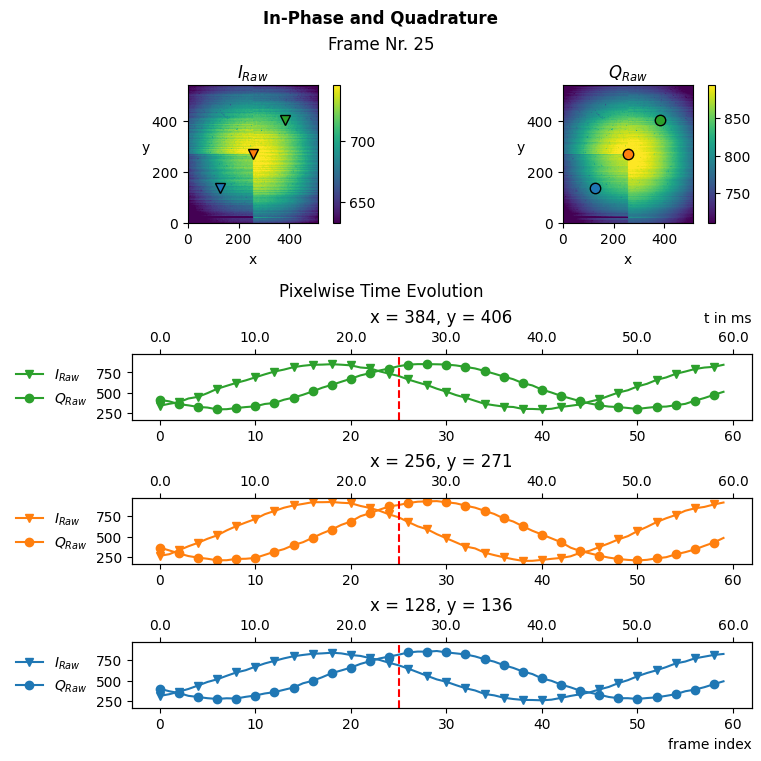

In [23]:
# Select pixel coordinates whose time evolution is plotted
NPixels = 3
coords = np.array([np.linspace(1,axis,NPixels+2)[1:-1].astype(int) for axis in [height,width]]).T

# Select index of frame in stack which is plotted
indFrame = 25

DataPlotterInphaseQuadrature(coords,*dataRaw,indFrame=indFrame,frameRate=frameRate,stackLabels=['$I_{Raw}$','$Q_{Raw}$']).plot()

#### Saturation

A common cause of corrupted data is saturation. Two subtypes with different symptoms exist:
- Similar to conventional cameras, the individual channels $I$ and $Q$ can be saturated. Signals would exceed the full value range (0-1023) and are cut off.
    
    $\Rightarrow$ If $I$ and $Q$ values occur at the limits of the validity range during the measurement, you should reduce the integration time constant, sensitivity or oscillation amplitude of the illumination. Conversely, if the fraction of the full scale used is small, you may increase these parameters.
- A very strong, constant background can lead to the saturation of individual images, which are added together in the camera sensor to form one $I$ and $Q$ value per frame.
    
    $\Rightarrow$ If, under such conditions, there is unexpectedly no signal on both $I$ and $Q$ (i.e., both have a constant value of ~1023/2), activate the [background suppression](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#background-suppression).

*Note also, that the longer the period, the more light reaches the sensor. Thus, at higher reference frequencies, the signal level is lower with otherwise constant settings.*

#### Modulation/Demodulation Frequency Mismatch

If the reference frequency deviates significantly from the carrier frequency, an (unexpected) [signal loss may occur](http://localhost:8000/heliCamC4_UserManual/chapter5/chapter5.html#effective-signal-processing). This can be particularly noticeable with many integration periods. To find whether this occurs, the frequency can be [read out in real time](#Real-Time-Signals) if the reference signal is generated internally by the camera. If an [external reference signal](#Lock-In-Amplification) is fed in, synchronization problems can also be effectively rectified. Care should be taken, however, that the set reference frequency is at least as large as the actual frequency of the reference trigger input (if frequency scaling is switched to off). Also, any jitter on the reference signal accounted for via the [`LockInTargetExpectedFrequencyDeviation`](http://localhost:8000/ftrDesc/Root/LockInControl/LockInExpectedFrequencyDeviation.html) parameter.

### Processing

The raw measurement data must be processed further before it is meaningful. Processing steps that are common to most applications are detailed in the following paragraph.

#### Offset/Fixed Pattern Noise (FPN) Correction

Raw in-phase and quadrature data are subject to a static offset by half the full scale and additionally affected by a [pixel-dependent fixed pattern noise](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#fixed-pattern-noise). There are three main ways to estimate the offset that must be subtracted to obtain zero-centered data.

-   Time Average

    In some simple cases, it can be assumed that the values fluctuate around the center point in such a way that the offset corresponds to the time average of the measurement.

-   Function Fit

    If the time course of the signal is known in advance, one can resort to fitting. For instance, the lock-in amplification of a sinusoidal input signal, as generated by the internal signal generator, produces a slow oscillatory beat in $I$ and $Q$ if the input has a small frequency deviation compared to the reference. A sinusoidal oscillation may be fit, whose center-value corresponds to the offset.

-   Measurement 

    In general, the time evolution of the output is unknown, however. Then there is no way around experimentally measuring the offset. For this purpose, measurement data collected under the same conditions - except that only the constant part of the illumination is switched on and the time-variable part is switched off - are averaged. ***If the camera-internal signal generator is used***, the intensity modulation can be turned off and on by means of the feature `SignalGeneratorModulationMode` independently of the constant background.

In [24]:
# Code for interactive selection of the offset determination mode

options = [("Time Average","TimeAverage"),("Sinuoid Fit","SinusoidFit"),("Measurement","Measurement")]
description = "Offset Estimation Method"

w = widgets.RadioButtons(options=options, description=description,layout={'width': 'max-content'},style= {'description_width': 'initial'})
display(w)

RadioButtons(description='Offset Estimation Method', layout=Layout(width='max-content'), options=(('Time Avera…

##### AlgoLibrary

Fast implementations of the first two offset estimation methods are available via the Heliotis AlgoLibrary. Similarly to C4Utility, the AlgoLibrary must be located on the computer before it can be used. If you have not installed it, code not optimized for execution speed is run instead. 

In [25]:
# Code to load offset correction utilities (through Heliotis AlgoLibrary)

try:
    sys.path.append(os.environ.get("HELIOTIS_ALGOLIB_ROOT"))
    from C4Algos.python.c4.offset_map import offset_map

    print("The Heliotis AlgoLibrary has been successfully located.")
    
except:

    class offset_map:
        """Replacement code for offset calculation in Heliotis AlgoLibrary"""

        def __init__(self,IRaw,QRaw,height,width,method):

            if method=='lsq-circle':

                self.IOffsets,self.QOffsets = np.array([[np.linalg.lstsq(np.vstack((IRaw[:,y,x], QRaw[:,y,x], np.ones(len(IRaw)))).T,
                            IRaw[:,y,x]**2+QRaw[:,y,x]**2, rcond=None)[0][:-1]/2 for y in range(height)] for x in range(width)]).T
            
            elif method=='mean':
                self.IOffsets,self.QOffsets = np.mean(IRaw,axis=0),np.mean(QRaw,axis=0)
        
    print("The Heliotis AlgoLibrary could not be found.")

The Heliotis AlgoLibrary has been successfully located.


In [26]:
# remove masked and empty frames present in firmware versions <= 1.9.2
NEmptyFrames = 0 if parse(camera.remote_device.node_map.DeviceFirmwareVersion.value) > parse('1.9.2') else 2

def removeOffset(IRaw,QRaw,method):

    if method == 'TimeAverage':
        # Only if I and Q fluctuate symmetrically about their mean
        out = offset_map(IRaw,QRaw,height,width,'mean')
        I0,Q0 = out.IOffsets,out.QOffsets

    elif method == 'SinusoidFit':
        # Only valid on low-frequency beat signal (e.g. sinusoid input and small carrier/reference frequency mismatch)
        out = offset_map(IRaw,QRaw,height,width,'lsq-circle')
        I0,Q0 = out.IOffsets,out.QOffsets

    elif method == 'Measurement':
        # Only valid as is when illumination is driven by the camera-internal signal generator
        camera.remote_device.node_map.SignalGeneratorMode.value = 'Off'
        I0,Q0 = np.mean(acquire(camera)[:,NEmptyFrames:],axis=1)
        camera.remote_device.node_map.SignalGeneratorMode.value = wSignalGeneratorModulationMode.value

    I,Q = IRaw-I0,QRaw-Q0

    return I,Q,I0,Q0

In [27]:
# convert data to int for processing without overflow
IRaw,QRaw = dataRaw[:,NEmptyFrames:].astype(int)

# Offset removal
I,Q,I0,Q0 = removeOffset(IRaw,QRaw,method=w.value)

In [28]:
# Code to plot offset correction using template

class DataPlotterOffsetCorrection(DataPlotter):

    def __init__(self,coords,I0,Q0,IRaw,QRaw,frameRate=None):

        self.IRawDataTSP = self.extractDataTSP(IRaw,coords)
        self.QRawDataTSP = self.extractDataTSP(QRaw,coords)
        self.I0DataTSP = self.extractDataTSP(I0,coords)
        self.Q0DataTSP = self.extractDataTSP(Q0,coords)
        
        DataPlotter.__init__(self,coords,np.array([I0,Q0]),['$I_0$','$Q_0$'],frameRate,'Offset Correction','Offset Maps')

    def plotDataTSP(self):

        for i,ax in enumerate(self.axesTimeSeries[::-1]):

            ax.axhline(self.I0DataTSP[i],color=DataPlotter.colors[i],ls='--',label='$I_0$')
            ax.axhline(self.Q0DataTSP[i],color=DataPlotter.colors[i],ls=':',label='$Q_0$')

            self.plotLineTSP(self.IRawDataTSP[i],i,ax,marker=DataPlotter.markersHeatMap[0],label='$I_{Raw}$')
            self.plotLineTSP(self.QRawDataTSP[i],i,ax,marker=DataPlotter.markersHeatMap[1],label='$Q_{Raw}$')

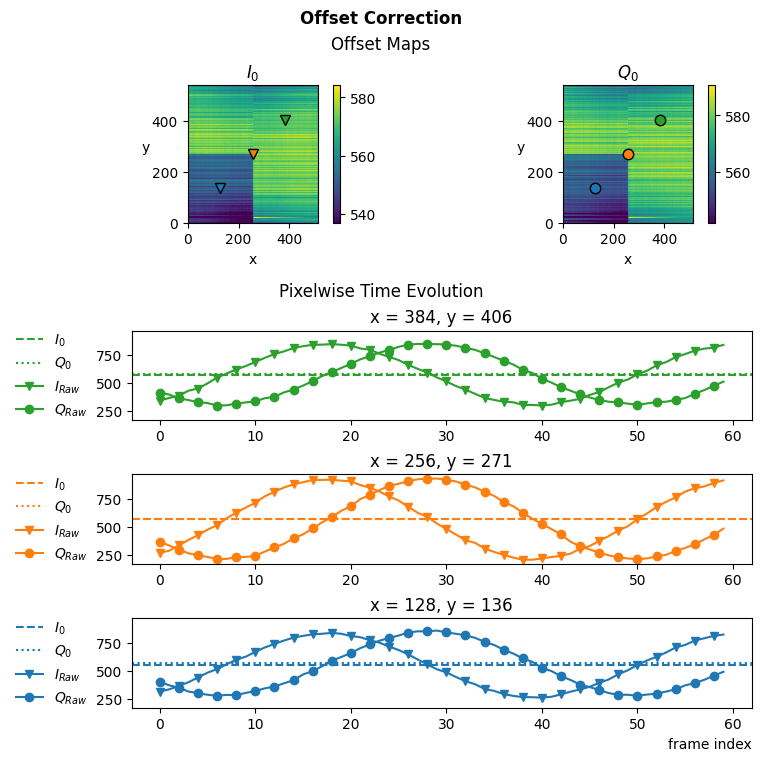

In [29]:
DataPlotterOffsetCorrection(coords,I0,Q0,IRaw,QRaw).plot()

#### Conversion to Polar Coordinates

Offset-corrected $I=I_{Raw}-I_0$ and $Q=Q_{Raw}-Q_0$ values can be [converted to polar coordinates](http://localhost:8000/heliCamC4_UserManual/chapter3/chapter3.html#conversion-to-polar-coordinates) to express the oscillation amplitude, $A$, and the phase difference compared to the reference, $\phi$.

$$A=\sqrt{I^2+Q^2}$$
$$\phi=arctan2(Q,I)$$

In [30]:
A = np.sqrt(I**2+Q**2)
φ = np.arctan2(Q,I)

In [31]:
# Code to plot amplitude and phase stack using template

class DataPlotterAmplitudePhase(DataPlotterFrameExtraction):

    def __init__(self,coords,A,φ,I=None,Q=None,indFrame=None,frameRate=None):

        self.ADataTSP = self.extractDataTSP(A,coords)
        self.φDataTSP = self.extractDataTSP(φ,coords)
        self.IDataTSP = self.extractDataTSP(I,coords) if I is not None else None
        self.QDataTSP = self.extractDataTSP(Q,coords) if Q is not None else None
        
        DataPlotterFrameExtraction.__init__(self,coords,np.array([A,φ]),['A','φ'],indFrame,frameRate,'Amplitude and Phase')

    def plotDataTSP(self):

        for i,ax in enumerate(self.axesTimeSeries[::-1]):

            self.plotLineTSP(self.ADataTSP[i],i,ax,marker=DataPlotter.markersHeatMap[0],label='A')
            secaxy = ax.twinx()
            self.plotLineTSP(self.φDataTSP[i],i,secaxy,marker=DataPlotter.markersHeatMap[1],label='φ')
            secaxy.legend(loc="center left",bbox_to_anchor=(1.05, 0.5),frameon=False,ncols=1)

            if self.IDataTSP is not None: self.plotLineTSP(self.IDataTSP[i],i,ax,label='I',ls='--',alpha=0.5)
            if self.QDataTSP is not None: self.plotLineTSP(self.QDataTSP[i],i,ax,label='Q',ls=':',alpha=0.5)

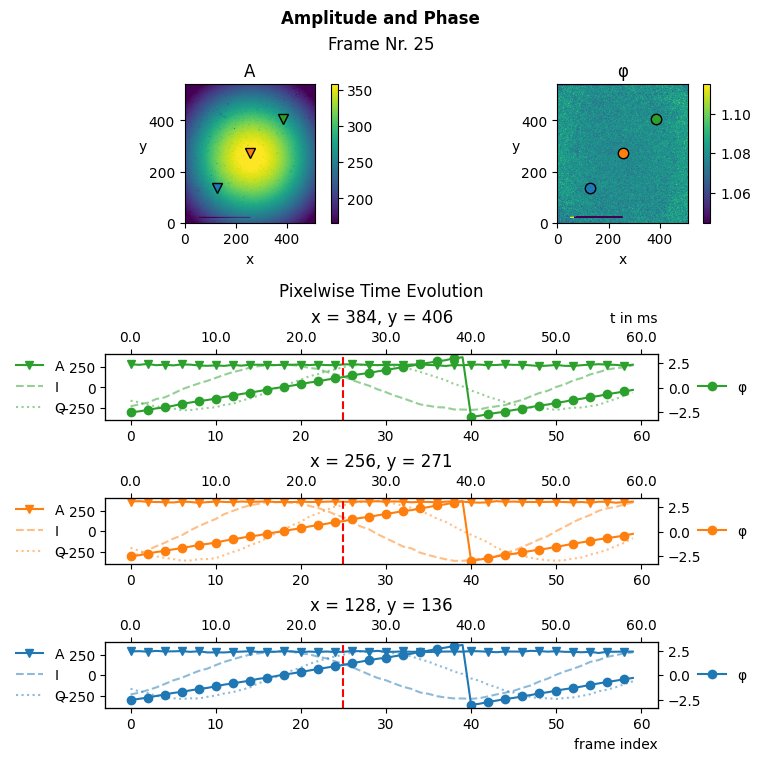

In [32]:
DataPlotterAmplitudePhase(coords,A,φ,I,Q,indFrame=indFrame,frameRate=frameRate).plot()

## Wrapping Up

### Freeing Resources

The connection to the camera is closed so that the heliCam C4 can once more be used by other programs.

In [33]:
camera.destroy()
h.reset()

The web server running the documentation can finally be terminated too.

In [34]:
p.kill()